<a href="https://colab.research.google.com/github/tanmayrathi/ML_PROJECT_TAE1/blob/main/80_20_Performance_Stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = '/content/drive/MyDrive/ML_DATASETS/healthcare-dataset-stroke-data.csv'

In [3]:
!pip install imbalanced-learn xgboost

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [5]:
df = pd.read_csv(file_path)
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
#Preprocesssing
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

/tmp/ipykernel_986/2638998204.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


In [8]:
le = LabelEncoder()

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [9]:
df.drop('id', axis=1, inplace=True)

In [10]:
#Features and Target
X = df.drop('stroke', axis=1)
y = df['stroke']

In [11]:
#Handle Class Imbalance (SMOTE)
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

In [12]:
#SAME Train-Test Split (80:20 FOR ALL MODELS)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
#Define all models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis()
}

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():

    # Use scaled data where required
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, auc, precision, recall, f1])

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("AUC:", auc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)


Logistic Regression
Accuracy: 0.8066838046272493
AUC: 0.8917324874438276
Precision: 0.7906066536203522
Recall: 0.8329896907216495
F1 Score: 0.8112449799196787

KNN
Accuracy: 0.8740359897172236
AUC: 0.9397298440391224
Precision: 0.8227960819234195
Recall: 0.9525773195876288
F1 Score: 0.882943143812709

Decision Tree
Accuracy: 0.8005141388174807
AUC: 0.8846190853819721
Precision: 0.7517301038062284
Recall: 0.8958762886597939
F1 Score: 0.8174976481655691

Random Forest
Accuracy: 0.9491002570694087
AUC: 0.9904134284959027
Precision: 0.935064935064935
Recall: 0.9649484536082474
F1 Score: 0.9497716894977168

SVM
Accuracy: 0.8555269922879177
AUC: 0.9299233412635474
Precision: 0.8309317963496637
Recall: 0.8917525773195877
F1 Score: 0.8602685231228244

Naive Bayes
Accuracy: 0.7830334190231363
AUC: 0.8520740153317473
Precision: 0.7486388384754991
Recall: 0.8505154639175257
F1 Score: 0.7963320463320464

Gradient Boosting
Accuracy: 0.8688946015424165
AUC: 0.9480639703938674
Precision: 0.841451766

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:19:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [30]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "AUC", "Precision", "Recall", "F1 Score"
])

results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df
# Sort based on best metric (recommended: F1 Score)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

# Add Rank column
results_df.insert(0, "Rank", range(1, len(results_df) + 1))

results_df
def highlight_best(row):
    return ['background-color: lightgreen' if row.name == results_df["F1 Score"].idxmax() else '' for _ in row]

results_df.style.apply(highlight_best, axis=1)


,Rank,Model,Accuracy,AUC,Precision,Recall,F1 Score
0,1,XGBoost,0.951671,0.991030,0.937126,0.968041,0.952333
1,2,Random Forest,0.949100,0.990413,0.935065,0.964948,0.949772
2,3,Extra Trees,0.940874,0.988053,0.926221,0.957732,0.941713
3,4,KNN,0.874036,0.939730,0.822796,0.952577,0.882943
4,5,Gradient Boosting,0.868895,0.948064,0.841452,0.908247,0.873575
5,6,SVM,0.855527,0.929923,0.830932,0.891753,0.860269
6,7,QDA,0.818509,0.898223,0.791864,0.862887,0.825851
7,8,AdaBoost,0.812853,0.905871,0.788571,0.853608,0.819802
8,9,Decision Tree,0.800514,0.884619,0.751730,0.895876,0.817498
9,10,LDA,0.806170,0.891373,0.787585,0.837113,0.811594


In [31]:
# Get best model based on F1 Score
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("🏆 Best Model:")
print("Model Name:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("AUC:", best_model["AUC"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1 Score"])

🏆 Best Model:
Model Name: XGBoost
Accuracy: 0.9516709511568123
AUC: 0.9910303991541105
Precision: 0.937125748502994
Recall: 0.9680412371134021
F1 Score: 0.9523326572008114


**Which model is best?**

**Random Forest, Extra Trees, or XGBoost performed best**

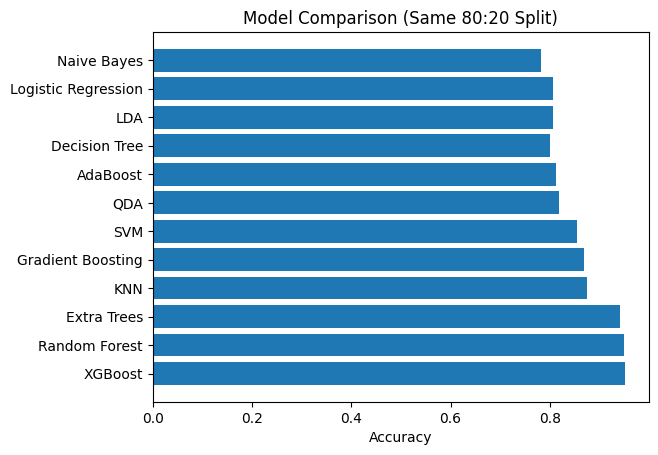

In [24]:
#Accuracy Comparision Graph
import matplotlib.pyplot as plt

plt.figure()
plt.barh(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Accuracy")
plt.title("Model Comparison (Same 80:20 Split)")
plt.show()

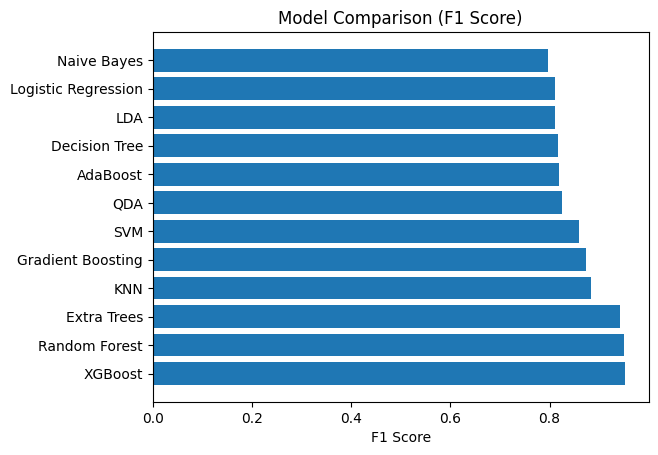

In [26]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(results_df["Model"], results_df["F1 Score"])
plt.xlabel("F1 Score")
plt.title("Model Comparison (F1 Score)")
plt.show()

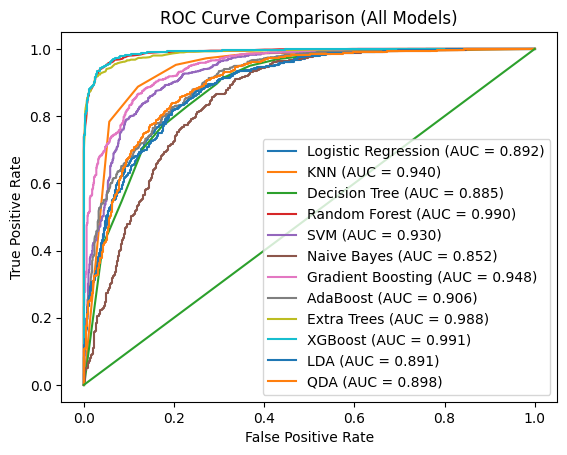

In [27]:
#ROC Curve for ALL Models
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in models.items():

    # Use scaled data where required
    if name in ["Logistic Regression", "KNN", "SVM"]:
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Random line
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()
plt.show()